# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Lailah\\vscode-project\\Credit-Card-Churning-Customers-Analysis-'

# Section 1

Section 1 content

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style('whitegrid')

In [6]:
df = pd.read_csv("Data/Cleaned_Data/Cleaned_Data.csv")
df.head(8)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,6,1,3,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,2,2,2,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048


In [11]:
df_transformed = pd.read_csv("Data/Cleaned_Data/Transformed_Data.csv")
df_transformed.head(8)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Attrition_Flag_Existing Customer,Education_Level_encoded,Card_Category_encoded
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39.0,5,...,42,1.172,0.061,1.0,1.0,0.0,0.0,1.0,2.0,0.0
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44.0,6,...,33,1.172,0.105,0.0,0.0,1.0,0.0,1.0,4.0,0.0
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36.0,4,...,20,1.172,0.000,1.0,1.0,0.0,0.0,1.0,4.0,0.0
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34.0,3,...,20,1.172,0.760,0.0,0.0,0.0,1.0,1.0,2.0,0.0
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21.0,5,...,28,1.172,0.000,1.0,1.0,0.0,0.0,1.0,1.0,0.0
5,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36.0,3,...,24,0.846,0.311,1.0,1.0,0.0,0.0,1.0,4.0,0.0
6,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46.0,6,...,31,0.722,0.066,1.0,1.0,0.0,0.0,1.0,0.0,2.0
7,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27.0,2,...,36,0.714,0.048,1.0,0.0,0.0,1.0,1.0,2.0,1.0


**Split data into training and testing set**

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['Attrition_Flag'], axis=1), 
    df['Attrition_Flag'], 
    test_size=0.2, 
    random_state=101
    )
print("* Train Set:", X_train.shape, "\n* Test set:", X_test.shape)

# df_encoded = pd.get_dummies(df, drop_first=True)


* Train Set: (8101, 19) 
* Test set: (2026, 19)


In [18]:
# from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE

# # 1. Split the data with stratification
# X_train, X_test, y_train, y_test = train_test_split(
#     df_transformed.drop(['Attrition_Flag'], axis=1),
#     df_transformed['Attrition_Flag'],
#     test_size=0.2,
#     random_state=101,
#     stratify=df_transformed['Attrition_Flag']   # <-- IMPORTANT
# )

# print("* Train Set:", X_train.shape, "\n* Test set:", X_test.shape)

# # 2. Apply SMOTE ONLY to the training set
# sm = SMOTE(random_state=101)
# X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# print("* Resampled Train Set:", X_train_res.shape, "\n* Resampled Labels:", y_train_res.shape)


In [49]:
from sklearn.pipeline import Pipeline

### Data Cleaning and Feature Engineering
from feature_engine.imputation import MeanMedianImputer
from feature_engine.imputation import CategoricalImputer
from feature_engine.encoding import OrdinalEncoder

### Feat Scaling
from sklearn.preprocessing import StandardScaler

### Feat Selection
from sklearn.feature_selection import SelectFromModel

### ML algorithms 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier


def PipelineOptimization(model):
  pipeline_base = Pipeline([
      ( 'median',  MeanMedianImputer(imputation_method='median',
                                     variables=['Customer_Age' , 'Dependent_count', 'Months_on_book', 
                                                'Total_Relationship_Count', 'Months_Inactive_12_mon', 
                                                'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
                                                'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                                                'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'
                                                ]) ),

      ( 'categorical_imputer', CategoricalImputer(imputation_method='frequent',
                                                        variables=['Gender', 'Education_Level', 'Marital_Status',
                                                                   'Income_Category', 'Card_Category']) ),

      ( "ordinal",OrdinalEncoder(encoding_method='arbitrary', 
                                 variables = ['Gender', 'Education_Level', 'Marital_Status',
                                              'Income_Category', 'Card_Category']) ), 

      ("feat_scaling", StandardScaler() ),

      ("feat_selection",  SelectFromModel(model) ),

      ("model", model ),


    ])

  return pipeline_base

**Creating The Pipeline**

In [61]:
from sklearn.model_selection import GridSearchCV

class HyperparameterTuning:
    def __init__(self, models, params):
        self.model = models
        self.params= params
        self.keys= models.keys()
        self.grid_searches={}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key}\n")
            model = PipelineOptimization(self.model[key])

            params = self.params[key]
            gs=GridSearchCV(model, params, cv=cv, n_jobs=n_jobs, verbose=verbose, scoring=scoring)
            gs.fit(X, y)
            self.grid_searches[key]=gs
    
    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
                
            }
            return pd.Series({**params, **d})
        rows = []
        for k in self.grid_searches:
            params=self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key="split{}_test_score".format(i)
                r=self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params),1))

                all_scores=np.hstack(scores)
                for p, s in zip(params, all_scores):
                    rows.append(row(k, s, p))
            
        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score', 'max_score', 'mean_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

models_search ={
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=101),
    "RandomForestClassifier": RandomForestClassifier(random_state=101),
    "LogisticRegression": LogisticRegression(random_state=101),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=101),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=101),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=101)
}

In [63]:
params_search = {
    "DecisionTreeClassifier":{},
    "RandomForestClassifier":{},
    "LogisticRegression":{},
    "GradientBoostingClassifier":{},
    "ExtraTreesClassifier":{},
    "AdaBoostClassifier":{}
    }

In [64]:
search = HyperparameterTuning(models=models_search, params=params_search)
search.fit(X_train, y_train,
            scoring='accuracy',
            n_jobs=-1,
            cv=2)


Running GridSearchCV for DecisionTreeClassifier

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for RandomForestClassifier

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for LogisticRegression

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for GradientBoostingClassifier

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for ExtraTreesClassifier

Fitting 2 folds for each of 1 candidates, totalling 2 fits

Running GridSearchCV for AdaBoostClassifier

Fitting 2 folds for each of 1 candidates, totalling 2 fits


**Summary Of Results**

In [65]:
grid_search_summary, grid_search_pipeline= search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,max_score,mean_score,std_score
2,RandomForestClassifier,0.957788,0.957788,0.957788,0.0
3,RandomForestClassifier,0.955309,0.957788,0.956548,0.00124
6,GradientBoostingClassifier,0.951123,0.951123,0.951123,0.0
7,GradientBoostingClassifier,0.949136,0.951123,0.950129,0.000994
10,AdaBoostClassifier,0.948161,0.948161,0.948161,0.0
11,AdaBoostClassifier,0.947901,0.948161,0.948031,0.00013
8,ExtraTreesClassifier,0.946927,0.946927,0.946927,0.0
9,ExtraTreesClassifier,0.940494,0.946927,0.94371,0.003216
0,DecisionTreeClassifier,0.9294,0.9294,0.9294,0.0
1,DecisionTreeClassifier,0.927407,0.9294,0.928404,0.000996


**Defining The New Hyperparameters For The Extensive Search**

In [70]:
models_search ={
    "RandomForestClassifier": RandomForestClassifier(random_state=0),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=0),
}
params_search = {
    "RandomForestClassifier": {"model__n_estimators": [40,30,20]},
    "GradientBoostingClassifier": {"model__n_estimators": [20,30,50]},
}

---

**Fit Again**

In [71]:
search = HyperparameterTuning(models=models_search, params=params_search)
search.fit(X_train, y_train,
            scoring='accuracy',
            n_jobs=-1,
            cv=2)


Running GridSearchCV for RandomForestClassifier

Fitting 2 folds for each of 3 candidates, totalling 6 fits

Running GridSearchCV for GradientBoostingClassifier

Fitting 2 folds for each of 3 candidates, totalling 6 fits


**Check Results**

In [72]:
grid_search_summary, grid_search_pipeline= search.score_summary(sort_by='mean_score')
grid_search_summary

,estimator,min_score,max_score,mean_score,std_score,model__n_estimators
2,RandomForestClassifier,0.959516,0.959516,0.959516,0.0,20
1,RandomForestClassifier,0.959269,0.959269,0.959269,0.0,30
0,RandomForestClassifier,0.957541,0.957541,0.957541,0.0,40
4,RandomForestClassifier,0.95358,0.959269,0.956425,0.002845,30
3,RandomForestClassifier,0.954815,0.957541,0.956178,0.001363,40
5,RandomForestClassifier,0.95284,0.959516,0.956178,0.003338,20
8,GradientBoostingClassifier,0.949889,0.949889,0.949889,0.0,50
11,GradientBoostingClassifier,0.943704,0.949889,0.946796,0.003093,50
7,GradientBoostingClassifier,0.943224,0.943224,0.943224,0.0,30
10,GradientBoostingClassifier,0.937778,0.943224,0.940501,0.002723,30


**Grab The Best Model and Parameter**

In [73]:
best_model = grid_search_summary.iloc[0,0]
best_model

'RandomForestClassifier'

In [74]:
grid_search_pipeline[best_model].best_params_

{'model__n_estimators': 30}

In [75]:
best_pipeline = grid_search_pipeline[best_model].best_estimator_
best_pipeline

Pipeline(steps=[('median',
                 MeanMedianImputer(variables=['Customer_Age', 'Dependent_count',
                                              'Months_on_book',
                                              'Total_Relationship_Count',
                                              'Months_Inactive_12_mon',
                                              'Contacts_Count_12_mon',
                                              'Credit_Limit',
                                              'Total_Revolving_Bal',
                                              'Avg_Open_To_Buy',
                                              'Total_Amt_Chng_Q4_Q1',
                                              'Total_Trans_Amt',
                                              'Total_Trans_Ct',
                                              'Total_Ct_Chng_Q4_Q1',
                                              'Avg_Utilization_Ratio'])),
                ('categ...
                                               'Card_Category'])),
                ('ordinal',
                 OrdinalEncoder(encoding_method='arbitrary',
                                variables=['Gender', 'Education_Level',
                                           'Marital_Status', 'Income_Category',
                                           'Card_Category'])),
                ('feat_scaling', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=RandomForestClassifier(random_state=0))),
                ('model',
                 RandomForestClassifier(n_estimators=30, random_state=0))])

**Checking The Most Important Features**

* These are the 7 most important features in descending order. The model was trained on them: 
['Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Relationship_Count', 'Avg_Utilization_Ratio']


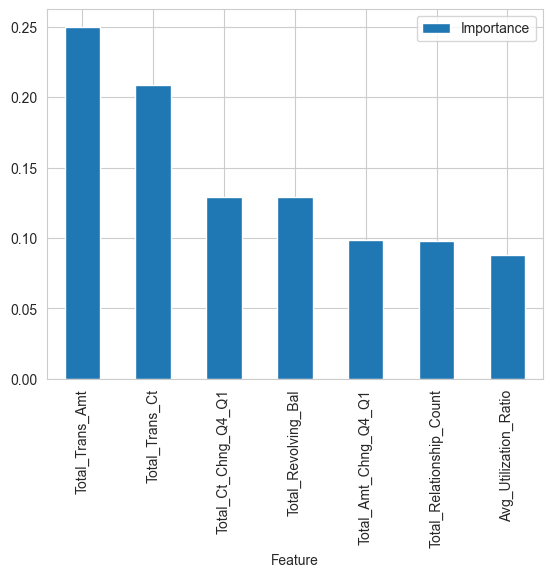

In [76]:
data_cleaning_feat_eng_steps = 3
# we get these steps with .steps[] starting from 0 until the value we assigned above
# then we .transform() to the train set and extract the columns
columns_after_data_cleaning_feat_eng = (Pipeline(best_pipeline.steps[:data_cleaning_feat_eng_steps])
                                        .transform(X_train)
                                        .columns)

# we get the boolean list indicating the best features with best_pipeline['feat_selection'].get_support()
# and use this list to subset columns_after_data_cleaning_feat_eng
best_features = columns_after_data_cleaning_feat_eng[best_pipeline['feat_selection'].get_support()].to_list()


# create DataFrame to display feature importance
df_feature_importance = (pd.DataFrame(data={
          'Feature': best_features,
          'Importance': best_pipeline['model'].feature_importances_})
  .sort_values(by='Importance', ascending=False)
  )

# Most important features statement and plot
print(f"* These are the {len(best_features)} most important features in descending order. "
      f"The model was trained on them: \n{df_feature_importance['Feature'].to_list()}")


df_feature_importance.plot(kind='bar',x='Feature',y='Importance')
plt.show()

**Evaluate Pipeline**

In [77]:
from sklearn.metrics import classification_report, confusion_matrix

def confusion_matrix_and_report(X,y,pipeline,label_map):

  prediction = pipeline.predict(X)

  print('---  Confusion Matrix  ---')
  print(pd.DataFrame(confusion_matrix(y_true=prediction, y_pred=y),
        columns=[ ["Actual " + sub for sub in label_map] ], 
        index= [ ["Prediction " + sub for sub in label_map ]]
        ))
  print("\n")


  print('---  Classification Report  ---')
  print(classification_report(y, prediction),"\n")


def clf_performance(X_train,y_train,X_test,y_test,pipeline,label_map):
  print("#### Train Set #### \n")
  confusion_matrix_and_report(X_train,y_train,pipeline,label_map)

  print("#### Test Set ####\n")
  confusion_matrix_and_report(X_test,y_test,pipeline,label_map)

In [80]:
clf_performance(X_train=X_train, y_train=y_train,
                X_test=X_test, y_test=y_test,
                pipeline=best_pipeline,
                label_map= df['Attrition_Flag'].unique() 
                # In this case, the target variable is encoded as categories and we
                # get the values with .unique() 
                )

#### Train Set #### 

---  Confusion Matrix  ---
                             Actual Existing Customer Actual Attrited Customer
Prediction Existing Customer                     1308                        1
Prediction Attrited Customer                        2                     6790


---  Classification Report  ---
                   precision    recall  f1-score   support

Attrited Customer       1.00      1.00      1.00      1310
Existing Customer       1.00      1.00      1.00      6791

         accuracy                           1.00      8101
        macro avg       1.00      1.00      1.00      8101
     weighted avg       1.00      1.00      1.00      8101
 

#### Test Set ####

---  Confusion Matrix  ---
                             Actual Existing Customer Actual Attrited Customer
Prediction Existing Customer                      266                       40
Prediction Attrited Customer                       51                     1669


---  Classification Report  ---
   

---

NOTE

**Model Choice**
RandomForestClassifier was chosen because it achieved the highest mean cross‑validation score across all models tested. Its mean score of 0.9578 was the strongest overall, indicating that it generalised more consistently across folds than the Gradient Boosting alternatives.

**Feature Importance**
The model identifies customer transaction behavior as the strongest driver of attrition predictions.

Top contributors:
* Total_Trans_Amt (most important)
* Total_Trans_Ct

These dominate the model, indicating that how much and how often a customer transacts is the key signal of whether they will churn.

**Model Performance**

The Results suggest that the model has overfitted on the training data hence the poorer performance on the testing data this could be due to the imbalance. The training results show perfect performance across all metrics, indicating that the model has effectively memorised the training data. This is reinforced by the confusion matrix, where almost every sample is classified correctly. However, the test‑set results show a noticeable decline in precision, recall, and F1‑score. This gap between training and testing performance indicates overfittin.  ^he model fits the balanced training data extremely well but struggles to generalise to the distribution in the test set.

---